# Visualización de Análisis de Calidad - Capa Silver

## Descripción

Este notebook visualiza los resultados del **análisis de calidad de datos** generado para los datasets de la **capa Silver**.

A partir de los reportes producidos por el script `quality_analysis.py`, se presentan los indicadores de calidad obtenidos para cada dimensión evaluada, permitiendo comparar el desempeño de los distintos tipos de servicio y analizar su evolución durante el período **2023–2025**.

---

## Objetivos

- Visualizar los indicadores de calidad para cada dimensión evaluada.
- Identificar las dimensiones con menor desempeño en cada dataset.
- Comparar la calidad entre los distintos tipos de servicio.
- Analizar la evolución de los indicadores de calidad a lo largo del tiempo.

---

## Fuente de datos

| Elemento | Descripción |
|----------|-------------|
| **Origen** | Reportes de calidad generados por `quality_analysis.py`. |
| **Ubicación** | `data/silver/quality/_quality_reports/` |
| **Cobertura temporal** | 2023, 2024 y 2025. |
| **Datasets** | Yellow Taxi, Green Taxi y FHV. |

---

> **Resultado esperado:** Evaluar el nivel de calidad alcanzado por cada dataset, identificar oportunidades de mejora y validar que los datos de la **capa Silver** cumplan con los estándares definidos para el proyecto.

In [2]:
import os
import json
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Colores institucionales
COLORS = {
    'yellow': '#F4D03F',
    'green': '#58D68D',
    'fhv': '#5DADE2',
    'primary': '#2E86AB',
    'success': '#27AE60',
    'warning': '#F39C12',
    'danger': '#E74C3C'
}

# Dimensiones de calidad
QUALITY_DIMENSIONS = [
    'completitud',
    'precision',
    'unicidad',
    'validez',
    'consistencia'
]

DIMENSION_LABELS = {
    'completitud': 'Completitud',
    'precision': 'Precisión',
    'unicidad': 'Unicidad',
    'validez': 'Validez',
    'consistencia': 'Consistencia'
}

# Umbrales de calidad
THRESHOLDS = {
    'completitud': 0.90,
    'precision': 0.85,
    'unicidad': 0.80,
    'validez': 0.90,
    'consistencia': 0.90
}

# ============================================================
# CONFIGURACIÓN DE RUTAS
# ============================================================

def get_project_root():
    current = Path.cwd()
    while current != current.parent:
        if (current / "data" / "bronze").exists():
            return current
        current = current.parent
    return Path.cwd()

ROOT_DIR = get_project_root()
QUALITY_REPORTS_DIR = ROOT_DIR / "data" / "silver" / "quality" / "_quality_reports"

print("=" * 80)
print(" VISUALIZACIÓN - ANÁLISIS DE CALIDAD")
print("=" * 80)
print(f" Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" Reportes: {QUALITY_REPORTS_DIR}")

if not QUALITY_REPORTS_DIR.exists():
    print("\n❌ ERROR: No se encontraron reportes.")
    print("   Ejecuta primero: quality_analysis.py")
    exit()

 VISUALIZACIÓN - ANÁLISIS DE CALIDAD
 Fecha: 2026-07-17 02:00:36
 Reportes: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\quality\_quality_reports


In [4]:
# ============================================================
# CARGA DE REPORTES DE CALIDAD
# ============================================================

YEARS = [2023, 2024, 2025]
TAXI_TYPES = ['yellow', 'green', 'fhv']

def load_quality_report(taxi_type, year):
    """Carga un reporte de calidad para un tipo y año específico"""
    path = QUALITY_REPORTS_DIR / f"{taxi_type}_{year}_quality_report.json"
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_all_reports():
    """Carga todos los reportes disponibles"""
    reports = {}
    for taxi_type in TAXI_TYPES:
        reports[taxi_type] = {}
        for year in YEARS:
            report = load_quality_report(taxi_type, year)
            if report:
                reports[taxi_type][year] = report
    return reports

print(" Cargando reportes de calidad...")
ALL_REPORTS = load_all_reports()

# Contar reportes
total_reports = 0
for taxi_type in TAXI_TYPES:
    if taxi_type in ALL_REPORTS:
        total_reports += len(ALL_REPORTS[taxi_type])

print(f" Reportes cargados: {total_reports}")

print("\n Disponibilidad de reportes:")
for taxi_type in TAXI_TYPES:
    if taxi_type in ALL_REPORTS:
        years_found = list(ALL_REPORTS[taxi_type].keys())
        status = "✅" if years_found else "❌"
        print(f"   {status} {taxi_type.upper()}: {years_found if years_found else 'Sin datos'}")
    else:
        print(f"   ❌ {taxi_type.upper()}: No disponible")

 Cargando reportes de calidad...
 Reportes cargados: 9

 Disponibilidad de reportes:
   ✅ YELLOW: [2023, 2024, 2025]
   ✅ GREEN: [2023, 2024, 2025]
   ✅ FHV: [2023, 2024, 2025]


 1. RESUMEN GENERAL DE CALIDAD

 Resumen de Calidad por Tipo y Año:
  Tipo  Año  Score  Issues  Registros
YELLOW 2023  82.79       1   35552266
YELLOW 2024  82.80       1   35541974
YELLOW 2025  83.91       1   34914687
 GREEN 2023  83.13       1     683391
 GREEN 2024  83.16       1     591547
 GREEN 2025  84.22       1     507995
   FHV 2023  83.93       2   15519045
   FHV 2024  83.45       2   17175195
   FHV 2025  82.59       2   24440543


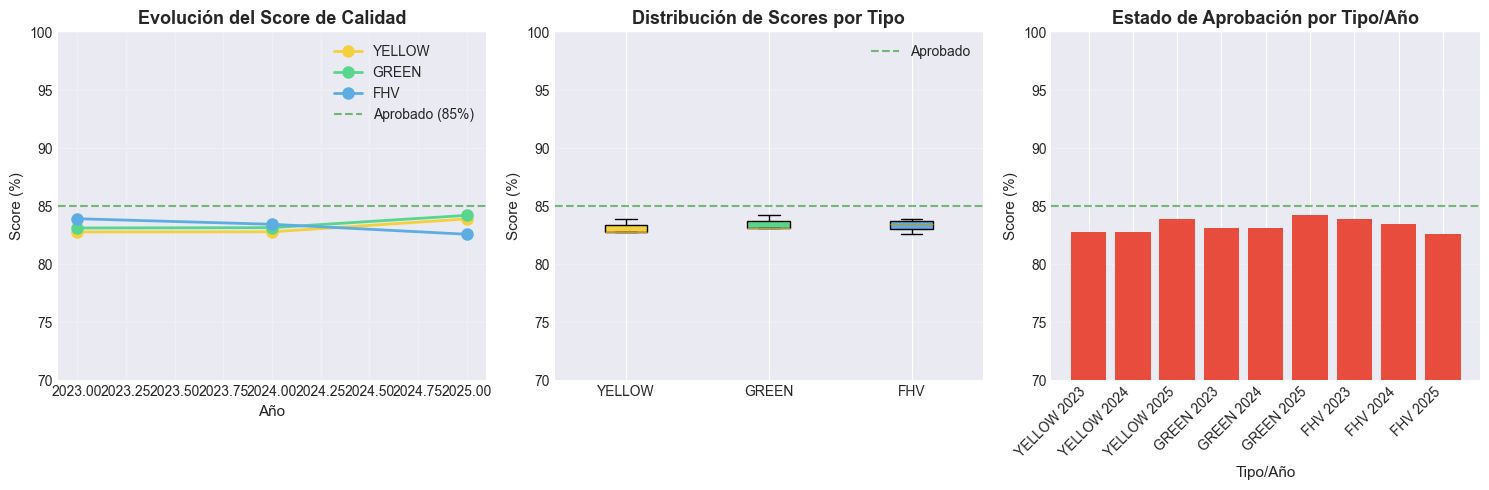


💡 CONCLUSIONES:
   📌 Mejor calidad: GREEN 2025 (84.2%)
   📌 Peor calidad: FHV 2025 (82.6%)


In [23]:
# ============================================================
# 1. RESUMEN GENERAL DE CALIDAD
# ============================================================

print("=" * 80)
print(" 1. RESUMEN GENERAL DE CALIDAD")
print("=" * 80)

summary_data = []
for taxi_type, years_data in ALL_REPORTS.items():
    for year, report in years_data.items():
        summary_data.append({
            'Tipo': taxi_type.upper(),
            'Año': year,
            'Score': report.get('overall_score', 0) * 100,
            'Issues': len(report.get('issues', [])),
            'Registros': report.get('total_records', 0)
        })

df_summary = pd.DataFrame(summary_data)

print("\n Resumen de Calidad por Tipo y Año:")
print(df_summary.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1: Score de calidad por tipo y año
ax1 = axes[0]
for taxi_type in TAXI_TYPES:
    if taxi_type not in ALL_REPORTS:
        continue
    years_data = ALL_REPORTS[taxi_type]
    years = sorted(years_data.keys())
    scores = [years_data[y].get('overall_score', 0) * 100 for y in years]
    
    color = COLORS.get(taxi_type, COLORS['primary'])
    ax1.plot(years, scores, marker='o', linewidth=2, markersize=8,
             label=taxi_type.upper(), color=color)

ax1.axhline(y=85, color='green', linestyle='--', alpha=0.5, label='Aprobado (85%)')
ax1.set_title('Evolución del Score de Calidad', fontsize=13, fontweight='bold')
ax1.set_xlabel('Año', fontsize=11)
ax1.set_ylabel('Score (%)', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.25)
ax1.set_ylim(70, 100)

# Gráfico 2: Boxplot de scores por tipo
ax2 = axes[1]
data_by_type = []
labels = []
for taxi_type in TAXI_TYPES:
    if taxi_type in ALL_REPORTS:
        scores = [y.get('overall_score', 0) * 100 for y in ALL_REPORTS[taxi_type].values()]
        data_by_type.append(scores)
        labels.append(taxi_type.upper())

bp = ax2.boxplot(data_by_type, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], [COLORS.get(t, COLORS['primary']) for t in TAXI_TYPES if t in ALL_REPORTS]):
    patch.set_facecolor(color)
ax2.axhline(y=85, color='green', linestyle='--', alpha=0.5, label='Aprobado')
ax2.set_title('Distribución de Scores por Tipo', fontsize=13, fontweight='bold')
ax2.set_ylabel('Score (%)', fontsize=11)
ax2.legend()
ax2.grid(axis='y', alpha=0.25)
ax2.set_ylim(70, 100)

# Gráfico 3: Estado de aprobación
ax3 = axes[2]
bars = ax3.bar(range(len(df_summary)), df_summary['Score'], color=colors)
ax3.set_title('Estado de Aprobación por Tipo/Año', fontsize=13, fontweight='bold')
ax3.set_xlabel('Tipo/Año', fontsize=11)
ax3.set_ylabel('Score (%)', fontsize=11)
ax3.set_xticks(range(len(df_summary)))
ax3.set_xticklabels([f"{row['Tipo']} {row['Año']}" for _, row in df_summary.iterrows()], rotation=45, ha='right')
ax3.axhline(y=85, color='green', linestyle='--', alpha=0.5)
ax3.grid(axis='y', alpha=0.25)
ax3.set_ylim(70, 100)

plt.tight_layout()
plt.show()

print("\n💡 CONCLUSIONES:")
if not df_summary.empty:
    mejor = df_summary.loc[df_summary['Score'].idxmax()]
    peor = df_summary.loc[df_summary['Score'].idxmin()]
    print(f"   📌 Mejor calidad: {mejor['Tipo']} {mejor['Año']} ({mejor['Score']:.1f}%)")
    print(f"   📌 Peor calidad: {peor['Tipo']} {peor['Año']} ({peor['Score']:.1f}%)")

📊 2. ANÁLISIS POR DIMENSIÓN DE CALIDAD

📋 Promedio por Dimensión:
Dimensión
Validez        100.00
Precisión      100.00
Consistencia    97.62
Completitud     84.06
Unicidad        22.35


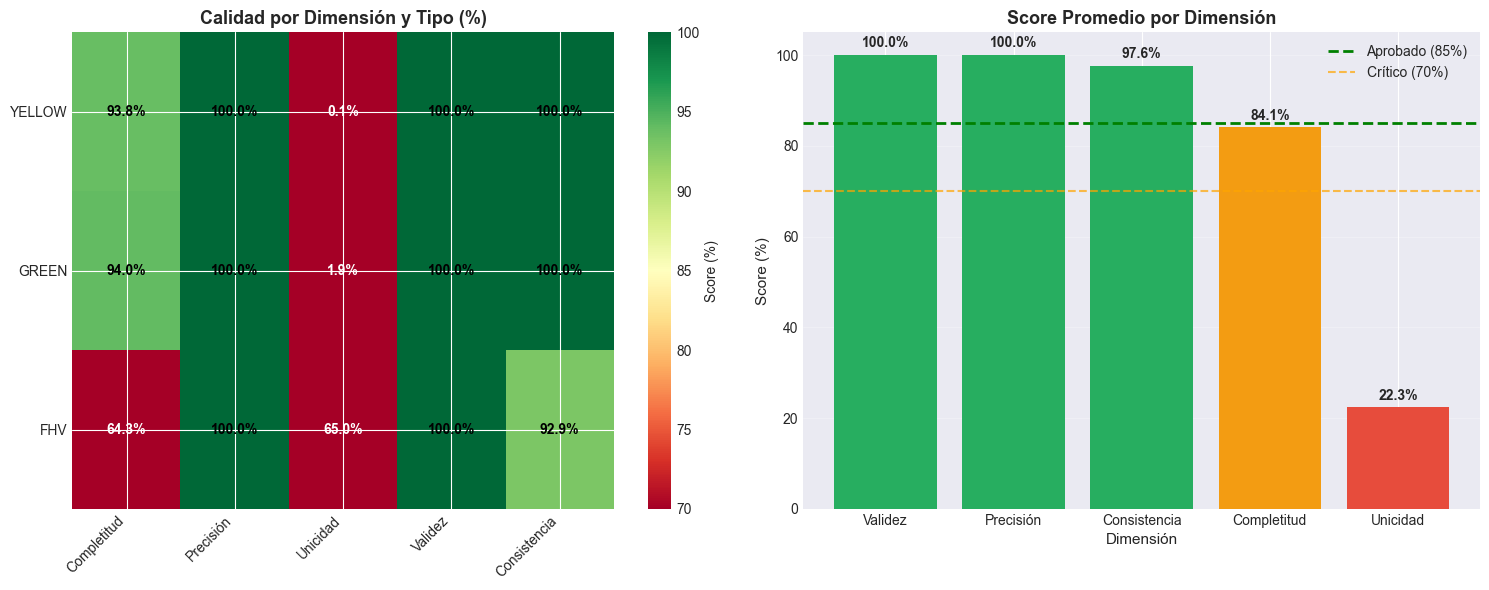


💡 DIMENSIONES CRÍTICAS:
   ✅ Validez: 100.0% (excelente)
   ✅ Precisión: 100.0% (excelente)
   ✅ Consistencia: 97.6% (excelente)
   ⚠️ Completitud: 84.1% (por debajo del umbral 85%)
   ⚠️ Unicidad: 22.3% (por debajo del umbral 85%)


In [26]:
# ============================================================
# 2. ANÁLISIS POR DIMENSIÓN DE CALIDAD
# ============================================================

print("=" * 80)
print("📊 2. ANÁLISIS POR DIMENSIÓN DE CALIDAD")
print("=" * 80)

# Recolectar datos por dimensión
dimension_data = []
for taxi_type, years_data in ALL_REPORTS.items():
    for year, report in years_data.items():
        dimensions = report.get('dimensions', {})
        for dim, info in dimensions.items():
            if dim in QUALITY_DIMENSIONS:
                dimension_data.append({
                    'Tipo': taxi_type.upper(),
                    'Año': year,
                    'Dimensión': DIMENSION_LABELS.get(dim, dim),
                    'Score': info.get('score', 0) * 100,
                    'Passed': info.get('passed', False)
                })

df_dimensions = pd.DataFrame(dimension_data)

# Orden de dimensiones para consistencia (mismo orden que QUALITY_DIMENSIONS)
dim_order = [DIMENSION_LABELS[dim] for dim in QUALITY_DIMENSIONS]

print("\n📋 Promedio por Dimensión:")
dim_avg = df_dimensions.groupby('Dimensión')['Score'].mean().sort_values(ascending=False)
print(dim_avg.to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Heatmap de dimensiones por tipo
ax1 = axes[0]
pivot_data = df_dimensions.pivot_table(
    index='Tipo', 
    columns='Dimensión', 
    values='Score',
    aggfunc='mean'
)

# Reordenar columnas según dim_order
pivot_data = pivot_data.reindex(columns=dim_order)

# Reordenar filas para consistencia (Yellow, Green, FHV)
type_order = ['YELLOW', 'GREEN', 'FHV']
pivot_data = pivot_data.reindex(index=[t for t in type_order if t in pivot_data.index])

im = ax1.imshow(pivot_data.values, cmap='RdYlGn', vmin=70, vmax=100, aspect='auto')
ax1.set_xticks(range(len(pivot_data.columns)))
ax1.set_yticks(range(len(pivot_data.index)))
ax1.set_xticklabels(pivot_data.columns, rotation=45, ha='right')
ax1.set_yticklabels(pivot_data.index)
ax1.set_title('Calidad por Dimensión y Tipo (%)', fontsize=13, fontweight='bold')

# Añadir valores
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        val = pivot_data.iloc[i, j]
        if not pd.isna(val):
            color = 'white' if val < 80 else 'black'
            ax1.text(j, i, f'{val:.1f}%', ha='center', va='center', color=color, fontweight='bold')

plt.colorbar(im, ax=ax1, label='Score (%)')

# Gráfico 2: Score promedio por dimensión con umbrales
ax2 = axes[1]
# Ordenar dimensiones para el gráfico de barras
dims = dim_avg.index.tolist()
values = dim_avg.values.tolist()
colors = ['#27AE60' if v >= 85 else '#F39C12' if v >= 70 else '#E74C3C' for v in values]

bars = ax2.bar(dims, values, color=colors)
ax2.axhline(y=85, color='green', linestyle='--', linewidth=2, label='Aprobado (85%)')
ax2.axhline(y=70, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Crítico (70%)')
ax2.set_title('Score Promedio por Dimensión', fontsize=13, fontweight='bold')
ax2.set_xlabel('Dimensión', fontsize=11)
ax2.set_ylabel('Score (%)', fontsize=11)
ax2.legend()
ax2.grid(axis='y', alpha=0.25)
ax2.set_ylim(0, 105)

for bar, val in zip(bars, values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 DIMENSIONES CRÍTICAS:")
for dim, avg in dim_avg.items():
    if avg < 85:
        print(f"   ⚠️ {dim}: {avg:.1f}% (por debajo del umbral 85%)")
    elif avg >= 95:
        print(f"   ✅ {dim}: {avg:.1f}% (excelente)")
    else:
        print(f"   📌 {dim}: {avg:.1f}% (aceptable)")

 3. ANÁLISIS DETALLADO POR TIPO DE TAXI

 YELLOW

 Resumen por Año:
 Año  Score Total  Issues  Completitud  Precisión  Unicidad  Validez  Consistencia
2023        82.79       1        92.59     100.00      0.12   100.00        100.00
2024        82.80       1        92.59     100.00      0.13   100.00        100.00
2025        83.91       1        96.30      99.99      0.14   100.00        100.00


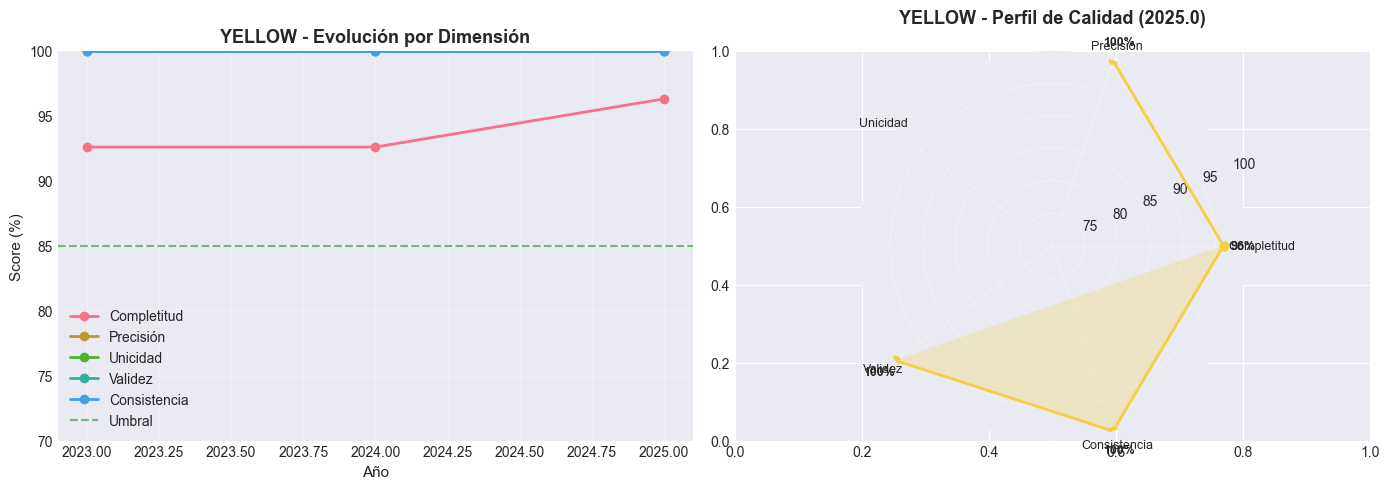


 GREEN

 Resumen por Año:
 Año  Score Total  Issues  Completitud  Precisión  Unicidad  Validez  Consistencia
2023        83.13       1        92.86     100.00      1.79   100.00        100.00
2024        83.16       1        92.86     100.00      2.03   100.00        100.00
2025        84.22       1        96.43      99.99      1.93   100.00        100.00


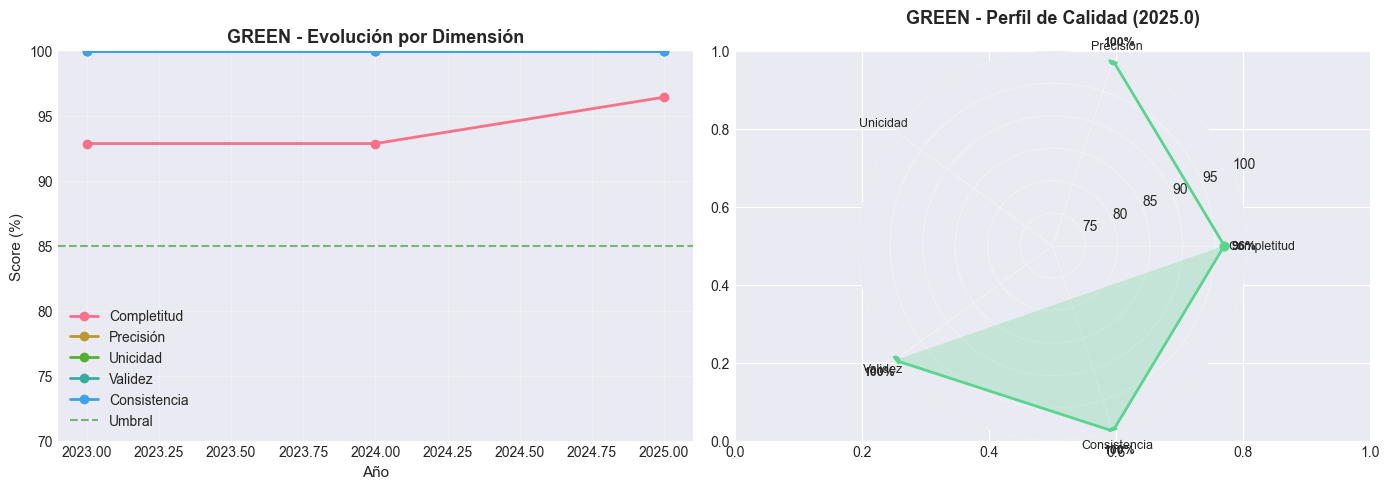


 FHV

 Resumen por Año:
 Año  Score Total  Issues  Completitud  Precisión  Unicidad  Validez  Consistencia
2023        83.93       2        64.29     100.00     69.05   100.00         92.86
2024        83.45       2        64.29     100.00     65.83   100.00         92.86
2025        82.59       2        64.29     100.00     60.11   100.00         92.86


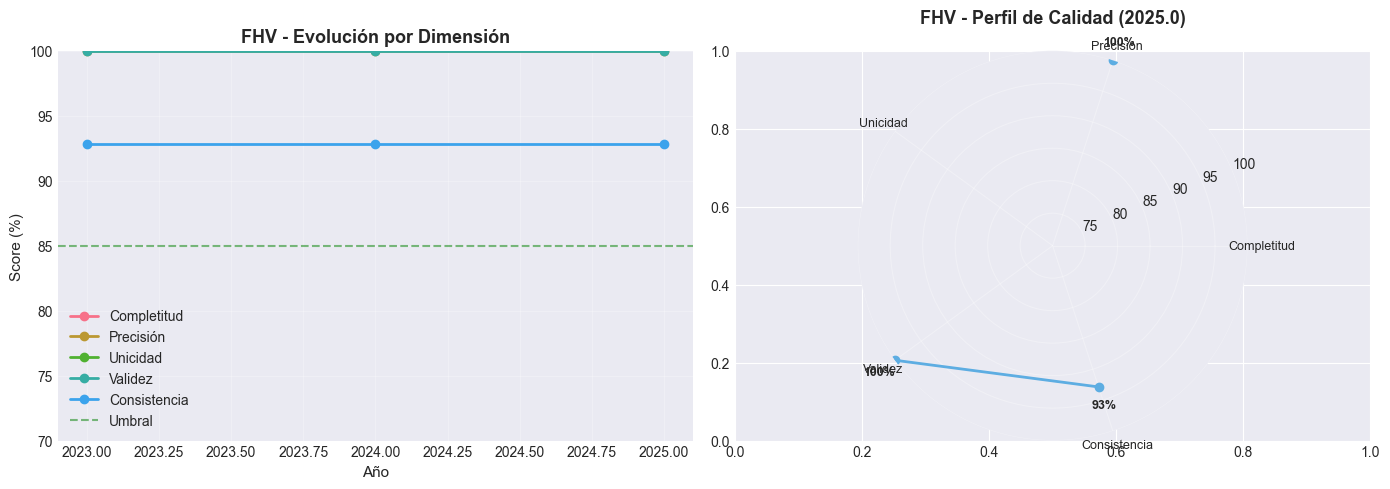

In [24]:
# ============================================================
# 3. ANÁLISIS DETALLADO POR TIPO DE TAXI
# ============================================================

print("=" * 80)
print(" 3. ANÁLISIS DETALLADO POR TIPO DE TAXI")
print("=" * 80)

for taxi_type in TAXI_TYPES:
    if taxi_type not in ALL_REPORTS:
        continue
    
    years_data = ALL_REPORTS[taxi_type]
    
    print(f"\n{'='*70}")
    print(f" {taxi_type.upper()}")
    print(f"{'='*70}")
    
    # Datos por año
    year_summary = []
    for year, report in years_data.items():
        dimensions = report.get('dimensions', {})
        dim_scores = {}
        for dim in QUALITY_DIMENSIONS:
            if dim in dimensions:
                dim_scores[DIMENSION_LABELS[dim]] = dimensions[dim].get('score', 0) * 100
        
        year_summary.append({
            'Año': year,
            'Score Total': report.get('overall_score', 0) * 100,
            'Issues': len(report.get('issues', [])),
            **dim_scores
        })
    
    # Verificar si hay datos
    if not year_summary:
        print("   ⚠️ Sin datos disponibles para este tipo")
        continue
    
    df_year = pd.DataFrame(year_summary)
    
    print("\n Resumen por Año:")
    print(df_year.to_string(index=False))
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Evolución de dimensiones
    ax1 = axes[0]
    years = df_year['Año'].tolist()
    dims_to_plot = [col for col in df_year.columns if col in DIMENSION_LABELS.values()]
    
    if dims_to_plot:
        for dim in dims_to_plot:
            values = df_year[dim].tolist()
            ax1.plot(years, values, marker='o', linewidth=2, label=dim)
        
        ax1.axhline(y=85, color='green', linestyle='--', alpha=0.5, label='Umbral')
        ax1.set_title(f'{taxi_type.upper()} - Evolución por Dimensión', fontsize=13, fontweight='bold')
        ax1.set_xlabel('Año', fontsize=11)
        ax1.set_ylabel('Score (%)', fontsize=11)
        ax1.legend(loc='best')
        ax1.grid(True, alpha=0.25)
        ax1.set_ylim(70, 100)
    else:
        ax1.text(0.5, 0.5, 'Sin datos de dimensiones', 
                ha='center', va='center', transform=ax1.transAxes, fontsize=12)
        ax1.set_title(f'{taxi_type.upper()} - Sin datos de dimensiones', fontsize=13, fontweight='bold')
    
    # Gráfico 2: Radar chart del último año
    ax2 = axes[1]
    last_year = df_year.iloc[-1]
    dims = [col for col in df_year.columns if col in DIMENSION_LABELS.values()]
    values = [last_year[dim] for dim in dims]
    
    if dims and values and any(v > 0 for v in values):
        from math import pi
        angles = [n / float(len(dims)) * 2 * pi for n in range(len(dims))]
        angles += angles[:1]
        values_radar = values + values[:1]
        
        ax2 = plt.subplot(122, projection='polar')
        ax2.plot(angles, values_radar, 'o-', linewidth=2, color=COLORS.get(taxi_type, COLORS['primary']))
        ax2.fill(angles, values_radar, alpha=0.25, color=COLORS.get(taxi_type, COLORS['primary']))
        ax2.set_xticks(angles[:-1])
        ax2.set_xticklabels(dims, fontsize=9)
        ax2.set_ylim(70, 100)
        ax2.set_title(f'{taxi_type.upper()} - Perfil de Calidad ({last_year["Año"]})', 
                      fontsize=13, fontweight='bold', pad=20)
        ax2.grid(True, alpha=0.3)
        
        for angle, value in zip(angles[:-1], values):
            ax2.text(angle, value + 3, f'{value:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'Sin datos de dimensiones', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_title(f'{taxi_type.upper()} - Sin datos de dimensiones', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

 4. ISSUES DETECTADOS

 Issues por Tipo y Año:
  Tipo  Año                    Issue
YELLOW 2023     Unicidad baja: 0.12%
YELLOW 2024     Unicidad baja: 0.13%
YELLOW 2025     Unicidad baja: 0.14%
 GREEN 2023     Unicidad baja: 1.79%
 GREEN 2024     Unicidad baja: 2.03%
 GREEN 2025     Unicidad baja: 1.93%
   FHV 2023 Completitud baja: 64.29%
   FHV 2023    Unicidad baja: 69.05%
   FHV 2024 Completitud baja: 64.29%
   FHV 2024    Unicidad baja: 65.83%
   FHV 2025 Completitud baja: 64.29%
   FHV 2025    Unicidad baja: 60.11%


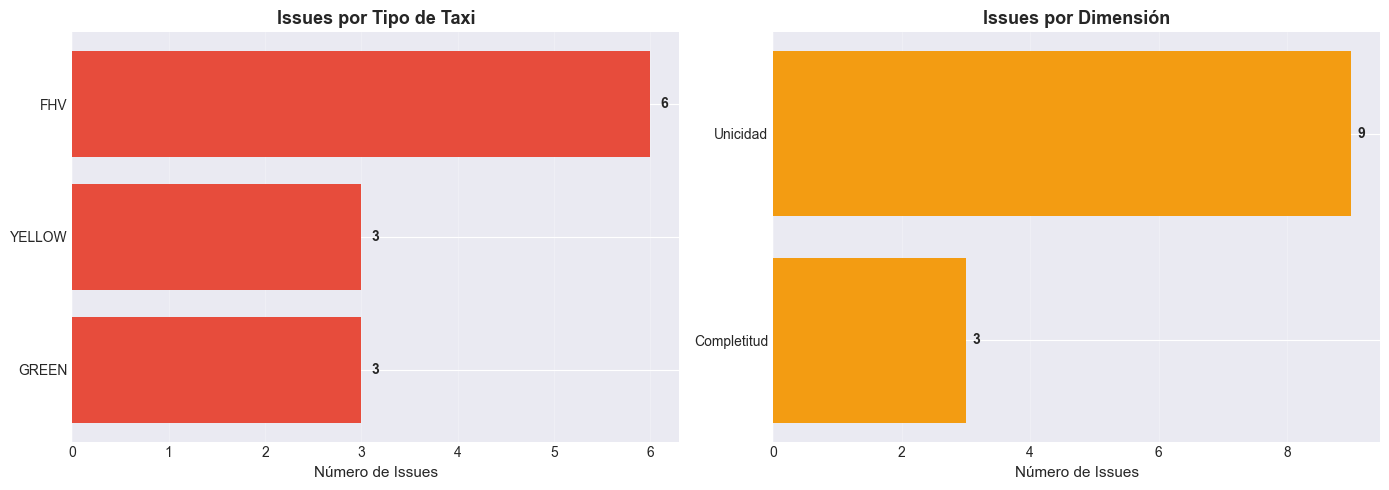


 TOTAL ISSUES: 12
   • Tipos con issues: 3
   • Años afectados: 3


In [15]:
# ============================================================
# 4. ISSUES DETECTADOS
# ============================================================

print("=" * 80)
print(" 4. ISSUES DETECTADOS")
print("=" * 80)

all_issues = []
for taxi_type, years_data in ALL_REPORTS.items():
    for year, report in years_data.items():
        for issue in report.get('issues', []):
            all_issues.append({
                'Tipo': taxi_type.upper(),
                'Año': year,
                'Issue': issue
            })

if all_issues:
    df_issues = pd.DataFrame(all_issues)
    
    print("\n Issues por Tipo y Año:")
    print(df_issues.to_string(index=False))
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Conteo de issues por tipo
    ax1 = axes[0]
    issue_counts = df_issues.groupby('Tipo').size().sort_values(ascending=True)
    bars = ax1.barh(issue_counts.index, issue_counts.values, color=COLORS['danger'])
    ax1.set_title('Issues por Tipo de Taxi', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Número de Issues', fontsize=11)
    ax1.grid(axis='x', alpha=0.25)
    
    for bar, val in zip(bars, issue_counts.values):
        ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{int(val)}', va='center', fontweight='bold')
    
    # Gráfico 2: Issues por dimensión
    ax2 = axes[1]
    issue_by_dim = df_issues['Issue'].str.extract(r'([A-Za-z]+)')[0].value_counts()
    issue_by_dim = issue_by_dim.sort_values(ascending=True)
    bars = ax2.barh(issue_by_dim.index, issue_by_dim.values, color=COLORS['warning'])
    ax2.set_title('Issues por Dimensión', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Número de Issues', fontsize=11)
    ax2.grid(axis='x', alpha=0.25)
    
    for bar, val in zip(bars, issue_by_dim.values):
        ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{int(val)}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n TOTAL ISSUES: {len(all_issues)}")
    print(f"   • Tipos con issues: {df_issues['Tipo'].nunique()}")
    print(f"   • Años afectados: {df_issues['Año'].nunique()}")
    
else:
    print("\n✅ No se detectaron issues en ningún reporte")

In [25]:
# ============================================================
# 5. RESUMEN EJECUTIVO FINAL
# ============================================================

print("=" * 80)
print(" 5. RESUMEN EJECUTIVO - ANÁLISIS DE CALIDAD")
print("=" * 80)

# Estadísticas globales
total_reports = 0
total_passed = 0
total_records = 0
all_scores = []

for taxi_type, years_data in ALL_REPORTS.items():
    for year, report in years_data.items():
        total_reports += 1
        if report.get('overall_passed', False):
            total_passed += 1
        total_records += report.get('total_records', 0)
        all_scores.append(report.get('overall_score', 0) * 100)

print(f"\n ESTADÍSTICAS GLOBALES:")
print(f"   • Reportes analizados: {total_reports}")
print(f"   • Total registros analizados: {total_records:,}")
print(f"   • Score promedio: {np.mean(all_scores):.1f}%")
print(f"   • Score mínimo: {np.min(all_scores):.1f}%")
print(f"   • Score máximo: {np.max(all_scores):.1f}%")

# Calcular promedio por dimensión
dim_avg = {}
for taxi_type, years_data in ALL_REPORTS.items():
    for year, report in years_data.items():
        dimensions = report.get('dimensions', {})
        for dim, info in dimensions.items():
            if dim in QUALITY_DIMENSIONS:
                if dim not in dim_avg:
                    dim_avg[dim] = []
                dim_avg[dim].append(info.get('score', 0) * 100)

print(f"\n SCORE PROMEDIO POR DIMENSIÓN:")
for dim, scores in dim_avg.items():
    label = DIMENSION_LABELS.get(dim, dim)
    avg = np.mean(scores)
    status = '✅' if avg >= 85 else '⚠️'
    print(f"   {status} {label}: {avg:.1f}%")

print(f"\n RECOMENDACIONES:")

# Identificar dimensiones con menor calidad
for dim, scores in dim_avg.items():
    avg = np.mean(scores)
    if avg < 85:
        label = DIMENSION_LABELS.get(dim, dim)
        print(f"   • Mejorar {label} (promedio: {avg:.1f}%)")

# Identificar tipo con menor calidad
type_scores = {}
for taxi_type, years_data in ALL_REPORTS.items():
    scores = [y.get('overall_score', 0) * 100 for y in years_data.values()]
    type_scores[taxi_type] = np.mean(scores)

if type_scores:
    worst_type = min(type_scores, key=type_scores.get)
    print(f"   • Priorizar revisión de {worst_type.upper()} (calidad más baja: {type_scores[worst_type]:.1f}%)")

print(f"\n UBICACIÓN DE ARCHIVOS:")
print(f"   • Reportes de calidad: {QUALITY_REPORTS_DIR}")
print("=" * 80)
print(" ANÁLISIS COMPLETADO")
print(f"   Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

 5. RESUMEN EJECUTIVO - ANÁLISIS DE CALIDAD

 ESTADÍSTICAS GLOBALES:
   • Reportes analizados: 9
   • Total registros analizados: 164,926,643
   • Score promedio: 83.3%
   • Score mínimo: 82.6%
   • Score máximo: 84.2%

 SCORE PROMEDIO POR DIMENSIÓN:
   ⚠️ Completitud: 84.1%
   ✅ Precisión: 100.0%
   ⚠️ Unicidad: 22.3%
   ✅ Validez: 100.0%
   ✅ Consistencia: 97.6%

 RECOMENDACIONES:
   • Mejorar Completitud (promedio: 84.1%)
   • Mejorar Unicidad (promedio: 22.3%)
   • Priorizar revisión de YELLOW (calidad más baja: 83.2%)

 UBICACIÓN DE ARCHIVOS:
   • Reportes de calidad: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\quality\_quality_reports
 ANÁLISIS COMPLETADO
   Fecha: 2026-07-17 02:18:15
